# Imports

In [20]:
from utils import sql
from matplotlib import pyplot as plt

# Découverte de la table "condition_occurrence"

In [6]:
measurement = sql("""
SELECT *
FROM omop.measurement
""")

In [4]:
measurement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4293 entries, 0 to 4292
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   measurement_id                 4293 non-null   int64         
 1   person_id                      4293 non-null   int64         
 2   measurement_concept_id         4293 non-null   int64         
 3   measurement_date               4293 non-null   object        
 4   measurement_datetime           4293 non-null   datetime64[ns]
 5   measurement_time               0 non-null      object        
 6   measurement_type_concept_id    4293 non-null   int64         
 7   operator_concept_id            4293 non-null   int64         
 8   value_as_number                2489 non-null   float64       
 9   value_as_concept_id            4293 non-null   int64         
 10  unit_concept_id                4293 non-null   int64         
 11  range_low        

In [5]:
measurement.describe()

,measurement_id,person_id,measurement_concept_id,measurement_datetime,measurement_type_concept_id,operator_concept_id,value_as_number,value_as_concept_id,unit_concept_id,visit_occurrence_id,measurement_source_concept_id
count,4293.000000,4293.000000,4.293000e+03,4293,4293.0,4293.0,2489.000000,4293.0,4293.0,4293.000000,4.293000e+03
mean,9198.000000,5806.864430,2.246132e+07,2017-03-13 07:59:24.818075904,32817.0,0.0,2931.580112,0.0,0.0,101092.640112,2.246132e+07
min,7052.000000,5751.000000,0.000000e+00,1970-04-20 10:40:42,32817.0,0.0,-3.700000,0.0,0.0,98895.000000,0.000000e+00
25%,8125.000000,5780.000000,3.020416e+06,2016-12-24 13:04:43,32817.0,0.0,7.800000,0.0,0.0,99874.000000,3.020416e+06
50%,9198.000000,5807.000000,3.630524e+07,2017-08-14 19:40:03,32817.0,0.0,33.800000,0.0,0.0,101086.000000,3.630524e+07
75%,10271.000000,5834.000000,4.305491e+07,2019-09-28 05:27:23,32817.0,0.0,92.800000,0.0,0.0,102172.000000,4.305491e+07
max,11344.000000,5860.000000,4.623633e+07,2026-07-26 21:09:50,32817.0,0.0,777661.000000,0.0,0.0,104617.000000,4.623633e+07
std,1239.426682,31.403334,1.928085e+07,NaN,0.0,0.0,28148.773264,0.0,0.0,1420.191777,1.928085e+07


In [6]:
measurement.head()

,measurement_id,person_id,measurement_concept_id,measurement_date,measurement_datetime,measurement_time,measurement_type_concept_id,operator_concept_id,value_as_number,value_as_concept_id,...,provider_id,visit_occurrence_id,visit_detail_id,measurement_source_value,measurement_source_concept_id,unit_source_value,unit_source_concept_id,value_source_value,measurement_event_id,meas_event_field_concept_id
0,7052,5834,3000905,2020-05-18,2020-05-18 02:21:28,None,32817,0,8.7,0,...,None,102172,None,6690-2,3000905,10*3/uL,None,8.7,None,None
1,7053,5834,3020416,2020-05-18,2020-05-18 02:21:28,None,32817,0,3.9,0,...,None,102172,None,789-8,3020416,10*6/uL,None,3.9,None,None
2,7054,5834,3000963,2020-05-18,2020-05-18 02:21:28,None,32817,0,13.8,0,...,None,102172,None,718-7,3000963,g/dL,None,13.8,None,None
3,7055,5834,3023314,2020-05-18,2020-05-18 02:21:28,None,32817,0,39.9,0,...,None,102172,None,4544-3,3023314,%,None,39.9,None,None
4,7056,5834,3023599,2020-05-18,2020-05-18 02:21:28,None,32817,0,80.2,0,...,None,102172,None,787-2,3023599,fL,None,80.2,None,None


### Top 20 des mesures biologiques :

In [10]:
top_measurement = sql("""
SELECT
    c.concept_name,
    COUNT(*)
FROM omop.measurement m
JOIN omop.concept c
ON m.measurement_concept_id=c.concept_id
GROUP BY c.concept_name
ORDER BY COUNT(*) DESC
LIMIT 20
""")

top_measurement

,concept_name,count
0,Tobacco smoking status,936
1,Body height,188
2,Pain severity - 0-10 verbal numeric rating [Sc...,164
3,Diastolic blood pressure,114
4,Systolic blood pressure,114
5,Body weight,111
6,Heart rate,105
7,Respiratory rate,104
8,Body mass index (BMI) [Ratio],96
9,"Within the last year, have you been afraid of ...",85


### Nombre de mesures biologiques par patient :

In [13]:
mesurements_per_patient = sql("""
SELECT
    person_id,
    COUNT(*) nb
FROM omop.measurement
GROUP BY person_id
""")

(array([18., 20., 57.,  6.,  2.,  4.,  0.,  2.,  0.,  1.]),
 array([29. , 33.1, 37.2, 41.3, 45.4, 49.5, 53.6, 57.7, 61.8, 65.9, 70. ]),
 <BarContainer object of 10 artists>)

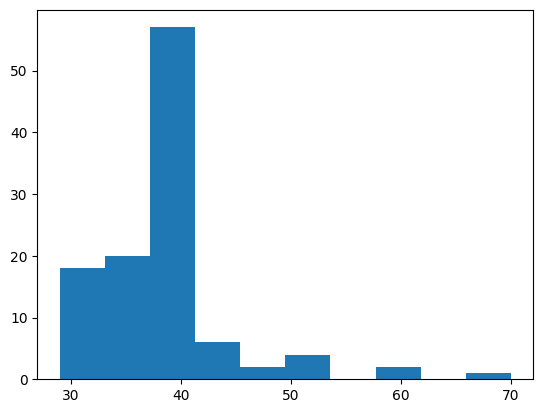

In [21]:
plt.hist(mesurements_per_patient["nb"])

In [19]:
mpp_sorted = mesurements_per_patient.sort_values(by=["nb"],ascending=False)
mpp_sorted.head()

,person_id,nb
74,5825,70
46,5797,60
51,5802,60
50,5801,52
100,5851,52
